         x1        x2  etiqueta
0 -0.008864  0.113353         0
1  0.242456 -0.075897         0
2 -0.014196 -0.070382         0
3 -0.165579 -0.143002         0
4  0.202125  0.327485         0


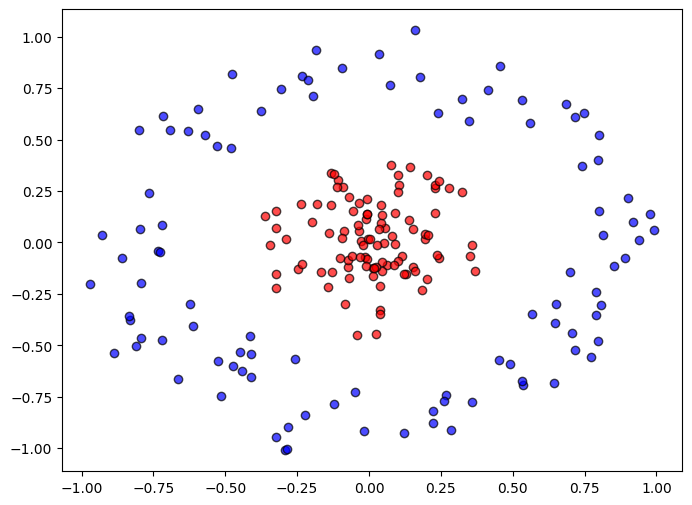

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
# 1. Configurar semilla para reproducibilidad
np.random.seed(42)
 
# 2. Definir parámetros
n_samples_per_class = 100  # 100 para malignas (0) y 100 para benignas (1)
n_total = n_samples_per_class * 2
 
# 3. Generar círculos concéntricos
# Clase 0: Círculo interno (Malignas)
theta_0 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_0 = np.random.uniform(0, 0.4, n_samples_per_class)  # Radio interno pequeño
x1_0 = r_0 * np.cos(theta_0)
x2_0 = r_0 * np.sin(theta_0)
y_0 = np.zeros(n_samples_per_class)
 
# Clase 1: Círculo externo (Benignas)
theta_1 = np.random.uniform(0, 2 * np.pi, n_samples_per_class)
r_1 = np.random.uniform(0.7, 1.0, n_samples_per_class)  # Radio externo grande
x1_1 = r_1 * np.cos(theta_1)
x2_1 = r_1 * np.sin(theta_1)
y_1 = np.ones(n_samples_per_class)
 
# 4. Combinar los datos
x1 = np.concatenate([x1_0, x1_1])
x2 = np.concatenate([x2_0, x2_1])
etiqueta = np.concatenate([y_0, y_1])
 
# 5. Agregar ruido al valor de x2
ruido = np.random.normal(0, 0.08, n_total)  # Ruido gaussiano con media 0 y desviación estándar 0.08
x2 = x2 + ruido
 
# 6. Crear un DataFrame de Pandas
df_celulas = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'etiqueta': etiqueta.astype(int)
})
 
# Mostrar las primeras 5 filas del dataset
print(df_celulas.head())
 
# 7. (Opcional) Visualizar los datos generados
plt.figure(figsize=(8, 6))
plt.scatter(df_celulas[df_celulas['etiqueta'] == 0]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 0]['x2'], 
            color='red', label='Maligna (0)', alpha=0.7, edgecolors='k')
plt.scatter(df_celulas[df_celulas['etiqueta'] == 1]['x1'], 
            df_celulas[df_celulas['etiqueta'] == 1]['x2'], 
            color='blue', label='Benigna (1)', alpha=0.7, edgecolors='k')

In [5]:
from sklearn.neural_network import MLPClassifier

X = df_celulas[['x1', 'x2']]
y = df_celulas['etiqueta']

modelo_mlp = MLPClassifier(
    hidden_layer_sizes=(16, 8, 4),
    learning_rate_init=0.03,
    max_iter=100,
    batch_size=200,
    solver='sgd',
    early_stopping=False,
    tol=0.001,
    n_iter_no_change=10,
    verbose=True,
    random_state=42
)

modelo_mlp.fit(X, y)

print(f'Epocas ejecutadas: {modelo_mlp.n_iter_}')
print(f'Perdida final: {modelo_mlp.loss_:.6f}')

Iteration 1, loss = 0.79760027
Iteration 2, loss = 0.78890472
Iteration 3, loss = 0.77740817
Iteration 4, loss = 0.76428563
Iteration 5, loss = 0.75055402
Iteration 6, loss = 0.73738011
Iteration 7, loss = 0.72752310
Iteration 8, loss = 0.72002530
Iteration 9, loss = 0.71415577
Iteration 10, loss = 0.70918851
Iteration 11, loss = 0.70450075
Iteration 12, loss = 0.70143901
Iteration 13, loss = 0.69897651
Iteration 14, loss = 0.69692119
Iteration 15, loss = 0.69523621
Iteration 16, loss = 0.69387984
Iteration 17, loss = 0.69280767
Iteration 18, loss = 0.69196285
Iteration 19, loss = 0.69129932
Iteration 20, loss = 0.69078669
Iteration 21, loss = 0.69038378
Iteration 22, loss = 0.69005916
Iteration 23, loss = 0.68979126
Iteration 24, loss = 0.68954941
Iteration 25, loss = 0.68931320
Iteration 26, loss = 0.68907420
Iteration 27, loss = 0.68882253
Iteration 28, loss = 0.68853837
Training loss did not improve more than tol=0.001000 for 10 consecutive epochs. Stopping.
Epocas ejecutadas: 28
P

In [6]:
# Prediccion para x1=0.1 y x2=0.1
nuevo_dato = pd.DataFrame({'x1': [0.1], 'x2': [0.1]})

clase_predicha = modelo_mlp.predict(nuevo_dato)[0]
probabilidades = modelo_mlp.predict_proba(nuevo_dato)[0]

nombre_clase = 'celula maligna' if clase_predicha == 1 else 'celula benigna'
print(f'Clase predicha: {clase_predicha} ({nombre_clase})')
print(f'Probabilidad de celula benigna (0): {probabilidades[0]:.4f}')
print(f'Probabilidad de celula maligna (1): {probabilidades[1]:.4f}')
print(f'Probabilidad de la clase predicha: {probabilidades[clase_predicha]:.4f}')

Clase predicha: 1 (celula maligna)
Probabilidad de celula benigna (0): 0.4916
Probabilidad de celula maligna (1): 0.5084
Probabilidad de la clase predicha: 0.5084
